# 03 · Electrical Model + BESS Analysis

Analyses the `DatacenterElectrical` loss accounting (PUE, UPS, PDU, transformer) and the 150 MWh / 50 MW `BESSModel` (C-rate efficiency, SOC derating, capacity fade).

In [ ]:
import sys, os
os.chdir("..")
sys.path.insert(0, ".")
import numpy as np, matplotlib.pyplot as plt
from c2g_env.physics.electrical import DatacenterElectrical
from c2g_env.physics.bess import BESSModel, PYSAM_ACTIVE

elec = DatacenterElectrical()
bess = BESSModel(dt_seconds=300)
print("BESS backend: PySAM" if PYSAM_ACTIVE else "BESS backend: Pure-Python (_SimpleBESSModel)")
print(f"BESS capacity  : {bess.E_NOM_MWH} MWh")
print(f"BESS P_max     : {bess.P_MAX_MW} MW")

BESS backend: Pure-Python (_SimpleBESSModel)
BESS capacity  : 150.0 MWh
BESS P_max     : 50.0 MW


## 3.1 PUE vs Utilisation Curve

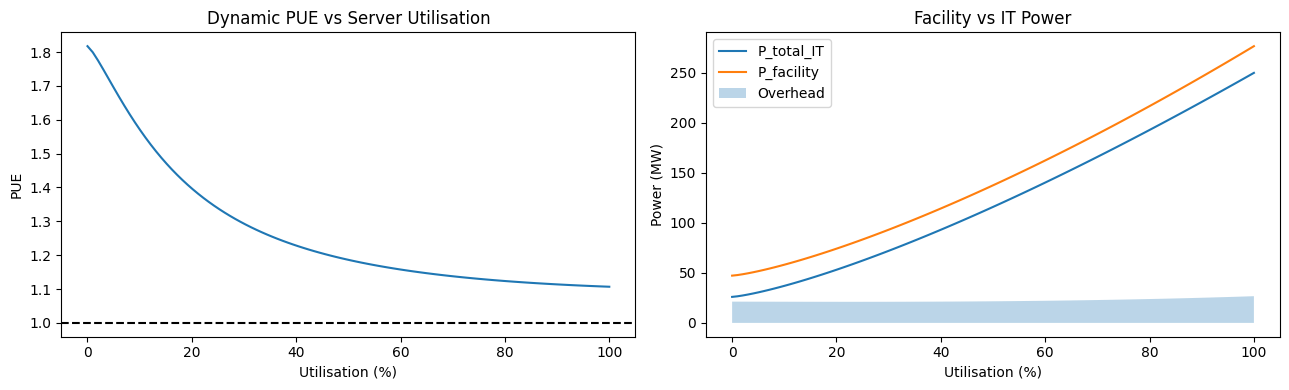

In [2]:
utils = np.linspace(0.0, 1.0, 100)
pues, p_total_its, p_facilities = [], [], []
for u in utils:
    elec.reset()
    out = elec.step(u, u, p_cool_A_mw=5.0, p_cool_B_mw=3.0)
    pues.append(out["pue_dynamic"])
    p_total_its.append(out["p_total_it_mw"])
    p_facilities.append(out["p_facility_mw"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(utils * 100, pues)
axes[0].set_xlabel("Utilisation (%)"); axes[0].set_ylabel("PUE")
axes[0].set_title("Dynamic PUE vs Server Utilisation"); axes[0].axhline(1.0, color="k", ls="--")

axes[1].plot(utils * 100, p_total_its, label="P_total_IT")
axes[1].plot(utils * 100, p_facilities, label="P_facility")
axes[1].fill_between(utils*100,
    np.array(p_facilities)-np.array(p_total_its), alpha=0.3, label="Overhead")
axes[1].set_xlabel("Utilisation (%)"); axes[1].set_ylabel("Power (MW)")
axes[1].set_title("Facility vs IT Power"); axes[1].legend()
plt.tight_layout(); plt.savefig("notebooks/fig_elec_pue.png", dpi=120); plt.show()

## 3.2 Loss Breakdown at Peak Load

Loss breakdown at 90% utilisation:
  IT Power       : 220.93 MW  (81.7%)
  UPS losses     : 10.01 MW  (3.7%)
  PDU losses     : 3.76 MW  (1.4%)
  Transformer    : 1.59 MW  (0.6%)
  Cooling        : 32.00 MW  (11.8%)
  Aux            : 2.00 MW  (0.7%)


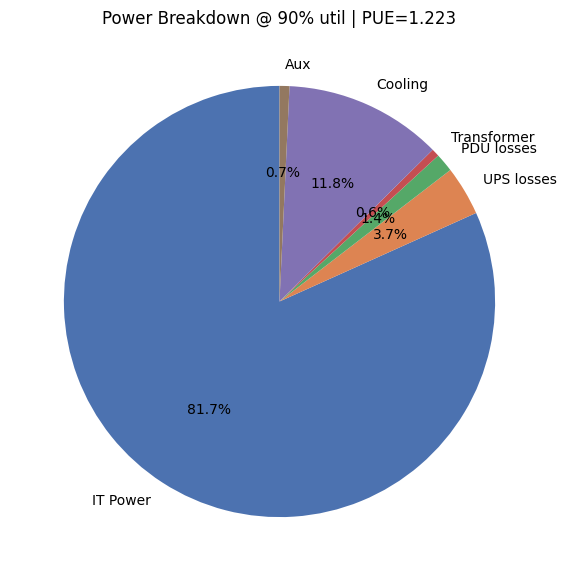

In [3]:
elec.reset()
out = elec.step(0.9, 0.9, p_cool_A_mw=20.0, p_cool_B_mw=12.0)
labels = ["IT Power", "UPS losses", "PDU losses", "Transformer", "Cooling", "Aux"]
sizes  = [out["p_total_it_mw"], out["p_ups_loss_mw"], out["p_pdu_loss_mw"],
          out["p_xfmr_loss_mw"], out["p_cooling_mw"], out["p_aux_mw"]]
print("Loss breakdown at 90% utilisation:")
for l, v in zip(labels, sizes):
    print(f"  {l:15s}: {v:.2f} MW  ({v/out['p_facility_mw']*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90,
    colors=["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860"])
ax.set_title(f"Power Breakdown @ 90% util | PUE={out['pue_dynamic']:.3f}")
plt.savefig("notebooks/fig_elec_breakdown.png", dpi=120); plt.show()

## 3.3 UPS Efficiency vs Load

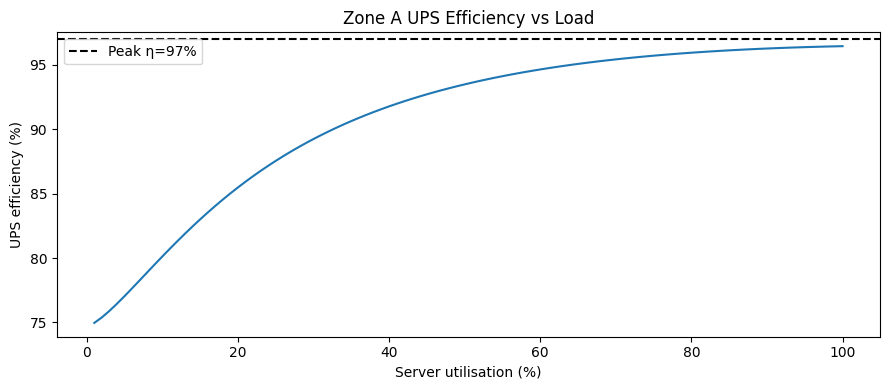

In [4]:
loads_A = np.linspace(0.01, 1.0, 100)
ups_etas = []
for u in loads_A:
    elec.reset()
    o = elec.step(u, u, 5.0, 3.0)
    ups_etas.append(o["ups_eta_A"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(loads_A * 100, np.array(ups_etas) * 100)
ax.set_xlabel("Server utilisation (%)"); ax.set_ylabel("UPS efficiency (%)")
ax.set_title("Zone A UPS Efficiency vs Load")
ax.axhline(97, color="k", ls="--", label="Peak η=97%"); ax.legend()
plt.tight_layout(); plt.savefig("notebooks/fig_elec_ups.png", dpi=120); plt.show()

## 3.4 BESS SOC Dynamics — Charge / Discharge Cycle

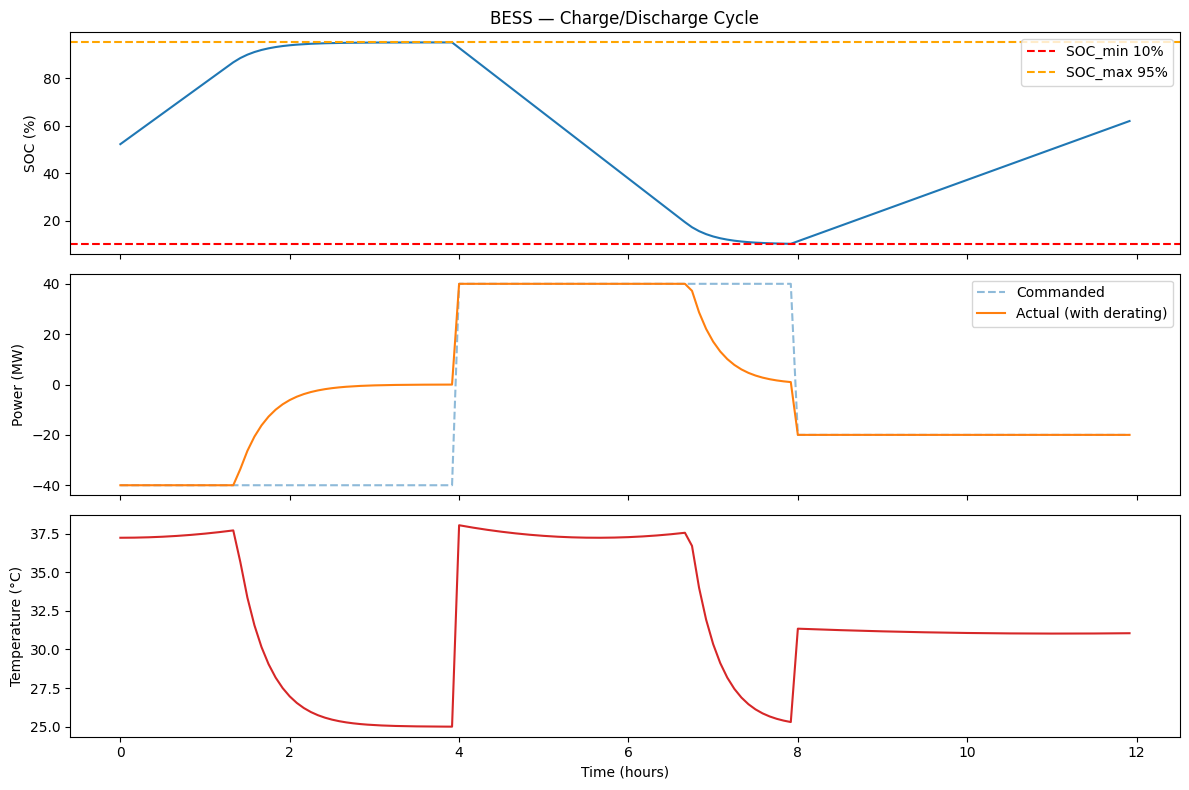

In [5]:
# Simulate a full charge-deplete-charge cycle
bess2 = BESSModel(dt_seconds=300)
bess2.reset(); bess2._soc = 0.5

soc_hist, actual_p_hist, temp_hist = [], [], []
commands = []
for tick in range(144):
    if tick < 48:    cmd = -40.0   # charge at -40 MW
    elif tick < 96:  cmd =  40.0   # discharge at +40 MW
    else:            cmd = -20.0   # gentle recharge
    commands.append(cmd)
    out = bess2.step(cmd)
    soc_hist.append(out["soc_fraction"] * 100)
    actual_p_hist.append(out["actual_power_mw"])
    temp_hist.append(out["temperature_C"])

t_h = np.arange(144) * 5 / 60

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(t_h, soc_hist, color="tab:blue"); axes[0].axhline(10, color="red", ls="--", label="SOC_min 10%")
axes[0].axhline(95, color="orange", ls="--", label="SOC_max 95%"); axes[0].set_ylabel("SOC (%)"); axes[0].legend()
axes[0].set_title("BESS — Charge/Discharge Cycle")

axes[1].plot(t_h, np.array(commands), ls="--", alpha=0.5, label="Commanded")
axes[1].plot(t_h, actual_p_hist, label="Actual (with derating)"); axes[1].set_ylabel("Power (MW)"); axes[1].legend()

axes[2].plot(t_h, temp_hist, color="tab:red"); axes[2].set_ylabel("Temperature (°C)")
axes[2].set_xlabel("Time (hours)")
plt.tight_layout(); plt.savefig("notebooks/fig_bess_cycle.png", dpi=120); plt.show()

## 3.5 Efficiency η(C-rate, SOC) Heatmap

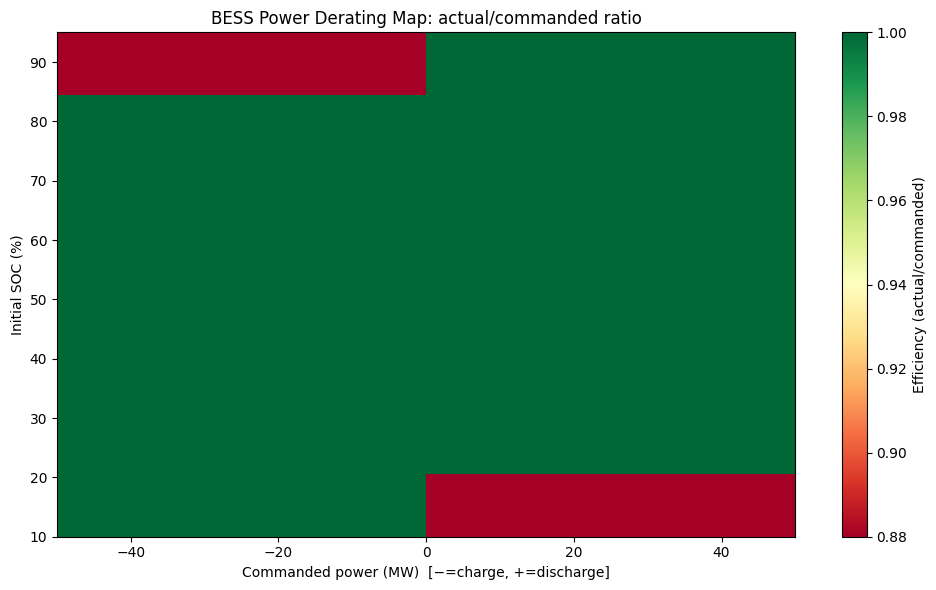

In [6]:
powers = np.linspace(-bess2.P_MAX_MW, bess2.P_MAX_MW, 40)
socs   = np.linspace(0.1, 0.95, 40)
eta_map = np.zeros((len(socs), len(powers)))

for i, soc in enumerate(socs):
    for j, p in enumerate(powers):
        b_tmp = BESSModel(dt_seconds=300)
        b_tmp.reset(); b_tmp._soc = soc
        out = b_tmp.step(p)
        # round-trip efficiency proxy: actual/commanded (avoid /0)
        if abs(p) > 0.5:
            eta_map[i, j] = abs(out["actual_power_mw"]) / abs(p)
        else:
            eta_map[i, j] = np.nan

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(eta_map, origin="lower", aspect="auto",
               extent=[powers[0], powers[-1], socs[0]*100, socs[-1]*100],
               vmin=0.88, vmax=1.0, cmap="RdYlGn")
plt.colorbar(im, ax=ax, label="Efficiency (actual/commanded)")
ax.set_xlabel("Commanded power (MW)  [−=charge, +=discharge]")
ax.set_ylabel("Initial SOC (%)")
ax.set_title("BESS Power Derating Map: actual/commanded ratio")
plt.tight_layout(); plt.savefig("notebooks/fig_bess_eta.png", dpi=120); plt.show()